Loading dataset...
✅ Sample Shape: (14999, 12)
Class Distribution:
loan_status
0    0.781852
1    0.218148
Name: proportion, dtype: float64

Split → Train: 8999 | Val: 3000 | Test: 3000

🚀 Running Monte Carlo (40 iterations) on 15,000 sample...

Simulation 1/40
Simulation 10/40
Simulation 20/40
Simulation 30/40
Simulation 40/40

SUMMARY - TRAIN | VALIDATION | TEST (15,000 Sample)
                                    F1           AUROC             MCC        
                                  mean     std    mean     std    mean     std
Model               Set                                                       
Decision Tree       Test        0.7241  0.0088  0.8292  0.0055  0.6447  0.0116
                    Train       1.0000  0.0000  1.0000  0.0000  1.0000  0.0000
                    Validation  0.7124  0.0143  0.8208  0.0097  0.6300  0.0185
Gradient Boosting   Test        0.7954  0.0053  0.9317  0.0015  0.7576  0.0068
                    Train       0.8208  0.0043  0.9496  0.0018  

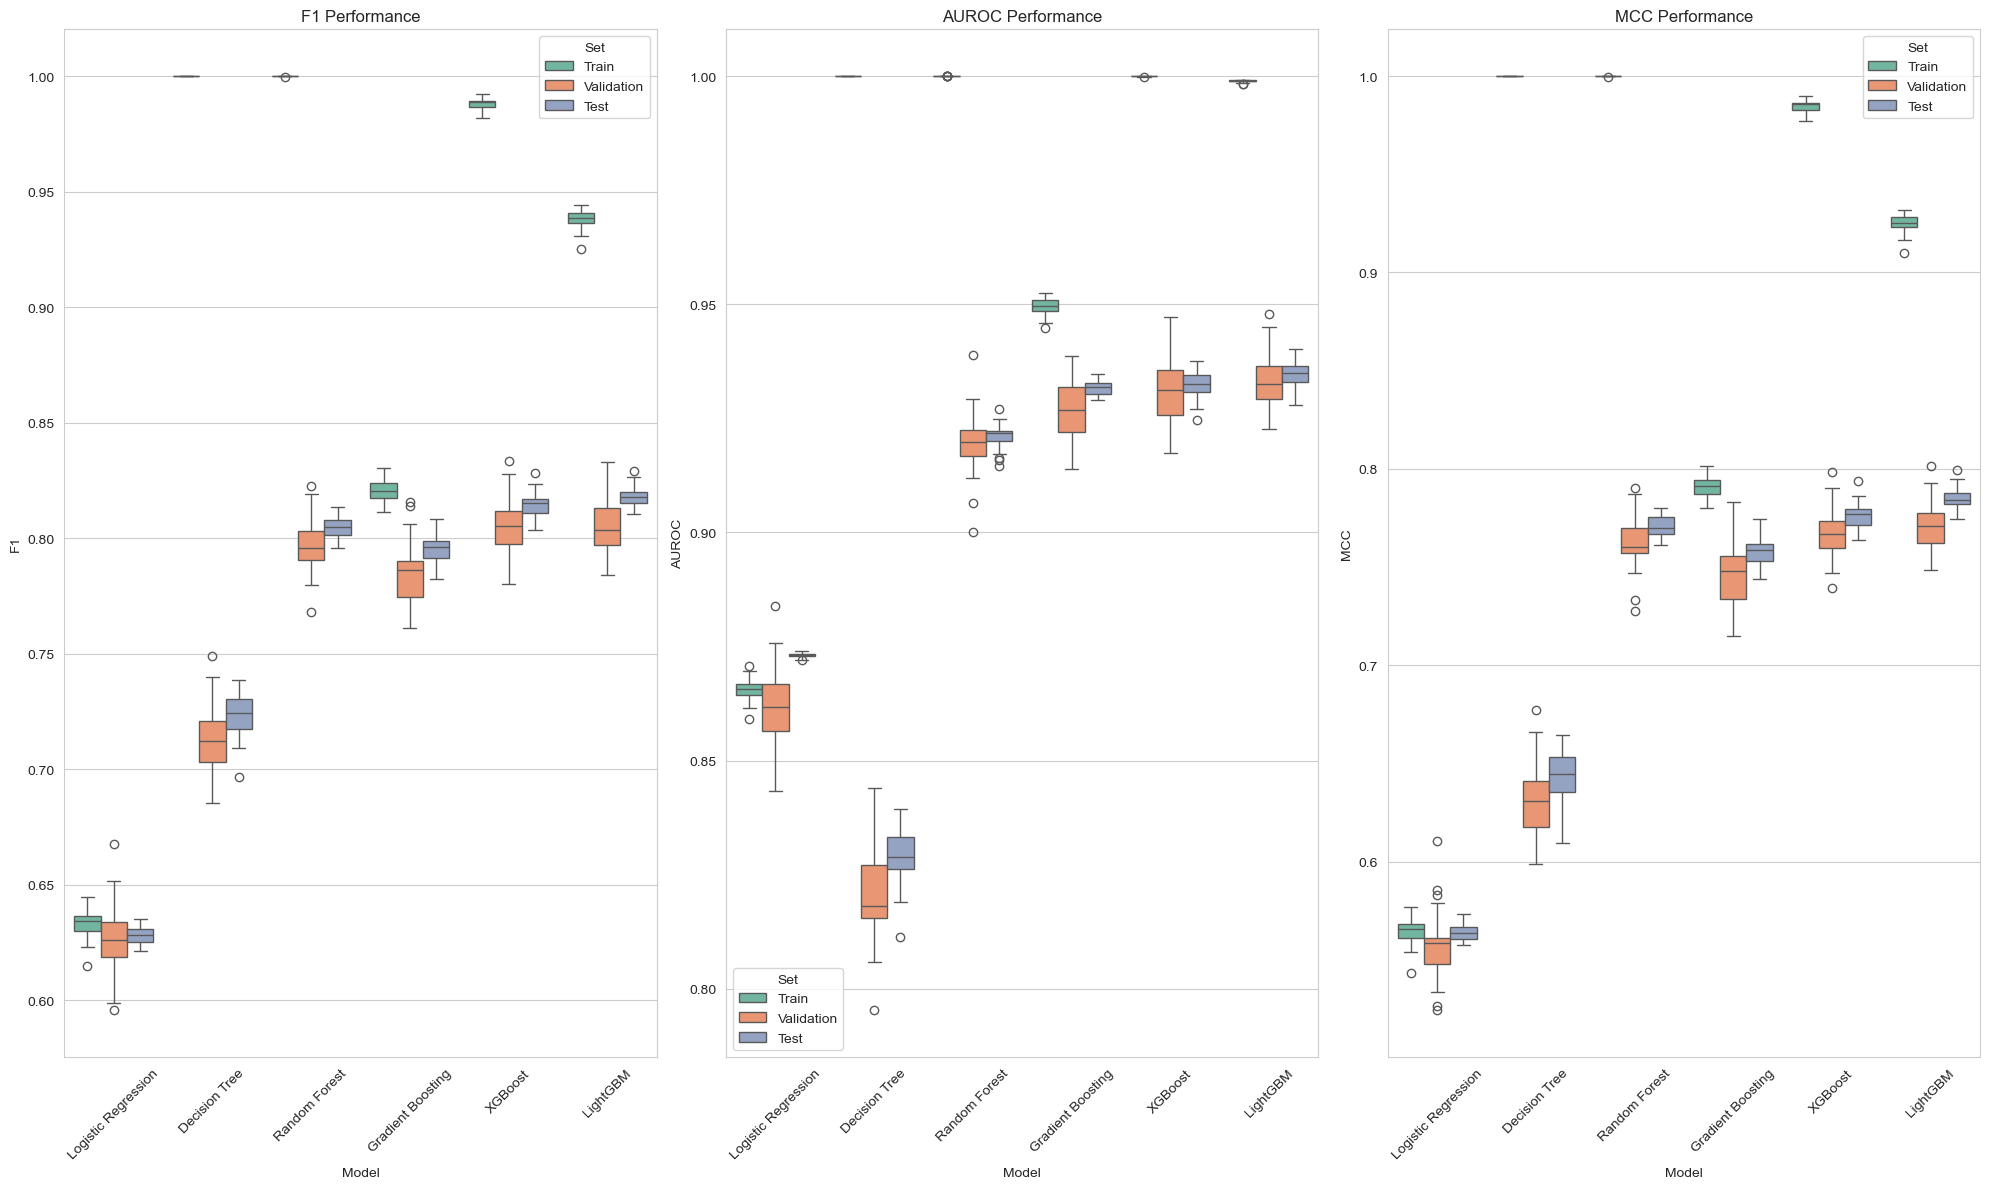

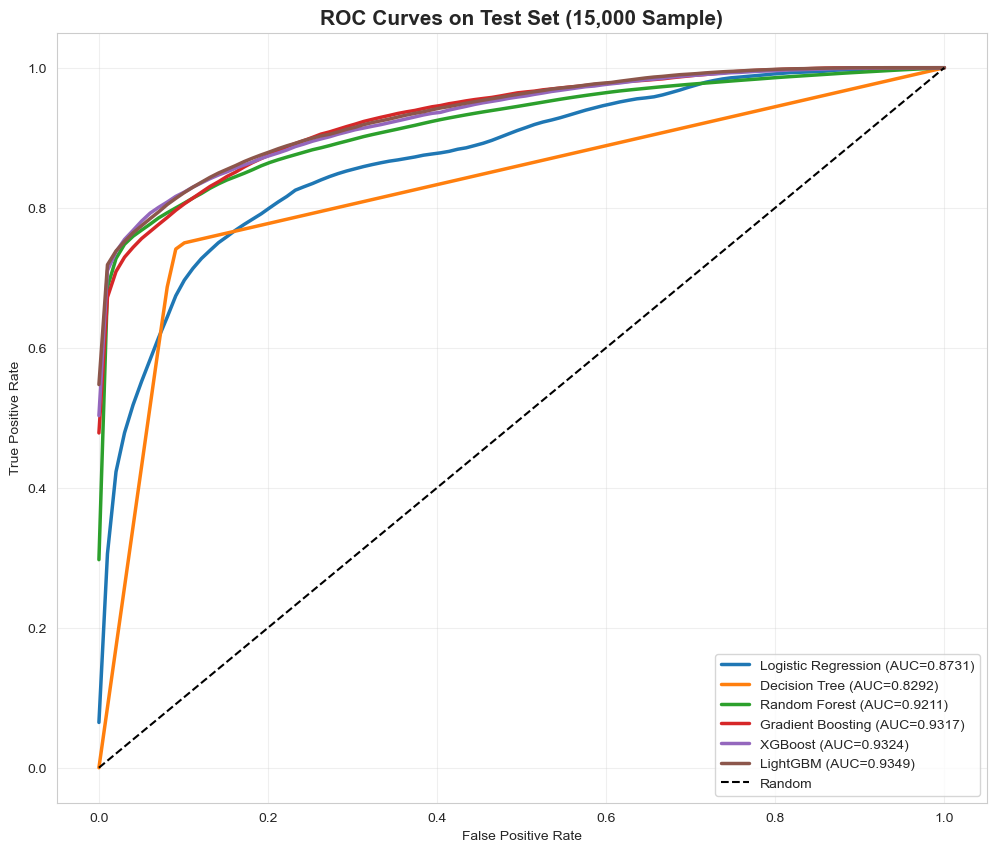


Generating Learning Curves for 15,000 sample...


In [ ]:
# =====================================================
# FINAL COMPREHENSIVE CREDIT RISK ANALYSIS - 15,000 SAMPLE
# Stratified Sample + Train/Val/Test + Monte Carlo + ROC + Learning Curves
# =====================================================

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
from math import pi

from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    matthews_corrcoef, roc_auc_score, roc_curve, auc
)

# ------------------- 1. LOAD DATA & CREATE 15,000 STRATIFIED SAMPLE -------------------
print("Loading dataset...")
df_original = pd.read_csv('credit_risk_dataset.csv')
target = 'loan_status'

sample_size = 15000

df_sample = df_original.groupby(target, group_keys=False).apply(
    lambda x: x.sample(n=int(sample_size * len(x) / len(df_original)), random_state=42)
)

df = df_sample.sample(n=sample_size, random_state=42) if len(df_sample) > sample_size else df_sample

print(f"✅ Sample Shape: {df.shape}")
print(f"Class Distribution:\n{df[target].value_counts(normalize=True)}")

# ------------------- 2. 3-WAY SPLIT -------------------
X = df.drop(columns=[target])
y = df[target]

X_train_full, X_temp, y_train_full, y_temp = train_test_split(
    X, y, test_size=0.4, stratify=y, random_state=42)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

print(f"\nSplit → Train: {len(X_train_full)} | Val: {len(X_val)} | Test: {len(X_test)}")

# ------------------- 3. PREPROCESSOR -------------------
numeric_features = df.select_dtypes(include=['int64', 'float64']).columns.drop(target, errors='ignore').tolist()
categorical_features = df.select_dtypes(include=['object']).columns.tolist()

preprocessor = ColumnTransformer([
    ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), 
                      ('scaler', StandardScaler())]), numeric_features),
    ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), 
                      ('encoder', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))]), categorical_features)
])

# ------------------- 4. MODELS -------------------
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=150, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=150, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=150, random_state=42, eval_metric='auc', verbosity=0),
    'LightGBM': LGBMClassifier(n_estimators=150, random_state=42, verbose=-1)
}

# ------------------- 5. METRICS -------------------
def p4_measure(y_true, y_pred):
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    return prec * rec * (1 - abs(prec - rec))

def evaluate_model(y_true, y_pred, y_prob=None):
    metrics = {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1': f1_score(y_true, y_pred, zero_division=0),
        'MCC': matthews_corrcoef(y_true, y_pred),
        'P4': p4_measure(y_true, y_pred),
    }
    if y_prob is not None:
        metrics['AUROC'] = roc_auc_score(y_true, y_prob)
    return metrics

# ------------------- 6. MONTE CARLO SIMULATION -------------------
def monte_carlo_simulation(n_sim=40):
    results = []
    roc_data = []
    
    print(f"\n🚀 Running Monte Carlo ({n_sim} iterations) on 15,000 sample...\n")
    
    for i in range(n_sim):
        if (i + 1) % 10 == 0 or i == 0:
            print(f"Simulation {i+1}/{n_sim}")
        
        X_train, X_val_mc, y_train, y_val_mc = train_test_split(
            X_train_full, y_train_full, test_size=0.25, stratify=y_train_full, random_state=42 + i
        )
        
        X_train_prep = preprocessor.fit_transform(X_train)
        X_val_prep = preprocessor.transform(X_val_mc)
        X_test_prep = preprocessor.transform(X_test)
        
        for model_name, model in models.items():
            model.fit(X_train_prep, y_train)
            
            for set_name, X_set, y_true in [
                ('Train', X_train_prep, y_train),
                ('Validation', X_val_prep, y_val_mc),
                ('Test', X_test_prep, y_test)
            ]:
                y_prob = model.predict_proba(X_set)[:, 1] if hasattr(model, "predict_proba") else None
                y_pred = (y_prob >= 0.5).astype(int)
                
                metrics = evaluate_model(y_true, y_pred, y_prob)
                metrics['Model'] = model_name
                metrics['Simulation'] = i + 1
                metrics['Set'] = set_name
                results.append(metrics)
            
            # ROC data for Test set
            if y_prob is not None:
                fpr, tpr, _ = roc_curve(y_test, y_prob)
                roc_data.append({
                    'Model': model_name, 'Simulation': i+1, 
                    'fpr': fpr, 'tpr': tpr, 'auc': auc(fpr, tpr)
                })
    
    return pd.DataFrame(results), pd.DataFrame(roc_data)

# ------------------- 7. LEARNING CURVES -------------------
def plot_learning_curves():
    print("\nGenerating Learning Curves for 15,000 sample...")
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    axes = axes.ravel()
    train_sizes = np.linspace(0.1, 1.0, 5)
    
    for idx, (model_name, model) in enumerate(models.items()):
        pipeline = make_pipeline(preprocessor, model)
        
        train_sizes_abs, train_scores, val_scores = learning_curve(
            pipeline, X_train_full, y_train_full,
            train_sizes=train_sizes, cv=5, scoring='f1',
            n_jobs=-1, random_state=42
        )
        
        train_mean = np.mean(train_scores, axis=1)
        train_std = np.std(train_scores, axis=1)
        val_mean = np.mean(val_scores, axis=1)
        val_std = np.std(val_scores, axis=1)
        
        ax = axes[idx]
        ax.plot(train_sizes_abs, train_mean, 'o-', label='Training Score', color='blue')
        ax.fill_between(train_sizes_abs, train_mean - train_std, train_mean + train_std, alpha=0.15, color='blue')
        ax.plot(train_sizes_abs, val_mean, 'o-', label='Cross-Val Score', color='red')
        ax.fill_between(train_sizes_abs, val_mean - val_std, val_mean + val_std, alpha=0.15, color='red')
        
        ax.set_title(model_name, fontsize=12, fontweight='bold')
        ax.set_xlabel('Training Set Size')
        ax.set_ylabel('F1 Score')
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('learning_curves_15000.png', dpi=300, bbox_inches='tight')
    plt.show()

# ------------------- RUN ANALYSIS -------------------
results_df, roc_df = monte_carlo_simulation(n_sim=40)

# Summary
summary = results_df.groupby(['Model', 'Set']).agg({
    'F1': ['mean', 'std'], 
    'AUROC': ['mean', 'std'], 
    'MCC': ['mean', 'std']
}).round(4)

print("\n" + "="*120)
print("SUMMARY - TRAIN | VALIDATION | TEST (15,000 Sample)")
print("="*120)
print(summary)

# ------------------- VISUALIZATIONS -------------------
sns.set_style("whitegrid")

# 1. Boxplots
plt.figure(figsize=(20, 12))
metrics_list = ['F1', 'AUROC', 'MCC']
for i, metric in enumerate(metrics_list):
    plt.subplot(1, 3, i+1)
    sns.boxplot(x='Model', y=metric, hue='Set', data=results_df, palette="Set2")
    plt.title(f'{metric} Performance')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('boxplots_train_val_test_15000.png', dpi=300, bbox_inches='tight')
plt.show()

# 2. ROC Curves
plt.figure(figsize=(12, 10))
for idx, model_name in enumerate(results_df['Model'].unique()):
    model_roc = roc_df[roc_df['Model'] == model_name]
    mean_auc = model_roc['auc'].mean()
    mean_fpr = np.linspace(0, 1, 100)
    mean_tpr = np.mean([np.interp(mean_fpr, row['fpr'], row['tpr']) for _, row in model_roc.iterrows()], axis=0)
    plt.plot(mean_fpr, mean_tpr, label=f'{model_name} (AUC={mean_auc:.4f})', linewidth=2.5)

plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves on Test Set (15,000 Sample)', fontsize=15, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.savefig('ROC_curves_test_set_15000.png', dpi=300, bbox_inches='tight')
plt.show()

# 3. Learning Curves
plot_learning_curves()

# 4. Overfitting Gap
train_df = results_df[results_df['Set'] == 'Train']
test_df = results_df[results_df['Set'] == 'Test']
gap = train_df.merge(test_df, on=['Model', 'Simulation'], suffixes=('_train', '_test'))
gap['F1_Gap'] = gap['F1_train'] - gap['F1_test']

plt.figure(figsize=(14, 8))
sns.boxplot(x='Model', y='F1_Gap', data=gap, palette="Reds")
plt.title('Overfitting Gap (Train F1 - Test F1) - 15,000 Sample', fontsize=15, fontweight='bold')
plt.axhline(0, color='black', linestyle='--')
plt.xticks(rotation=45)
plt.savefig('overfitting_gap_15000.png', dpi=300, bbox_inches='tight')
plt.show()

# ------------------- SAVE RESULTS -------------------
results_df.to_csv('monte_carlo_results_train_val_test_15000.csv', index=False)
summary.to_csv('summary_train_val_test_15000.csv')

print("\n🎉 Comprehensive Analysis for 15,000 Sample Completed Successfully!")
print("All files and plots have been saved.")